In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [3]:
df = pd.read_csv("16-diabetes.csv")

In [5]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
# DiabetesPedigreeFunction -> bireyin genetik olarak diyabete yatkınlığını temsil eden katsayıdır

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [11]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [13]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [15]:
# Glucose, BloodPressure, SkinThickness, Insulin -> min değerlerinin 0 olması mantıklı değil

In [17]:
df["Insulin"].value_counts()

Insulin
0      374
105     11
140      9
130      9
120      8
      ... 
178      1
127      1
510      1
16       1
112      1
Name: count, Length: 186, dtype: int64

In [19]:
df["BloodPressure"].value_counts()

BloodPressure
70     57
74     52
78     45
68     45
72     44
64     43
80     40
76     39
60     37
0      35
62     34
66     30
82     30
88     25
84     23
90     22
58     21
86     21
50     13
56     12
54     11
52     11
92      8
75      8
65      7
94      6
85      6
48      5
96      4
44      4
110     3
98      3
100     3
106     3
30      2
108     2
55      2
104     2
46      2
40      1
122     1
95      1
102     1
61      1
24      1
38      1
114     1
Name: count, dtype: int64

In [21]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [27]:
columns_to_check = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin','BMI']

for col in columns_to_check:
    zero_count = (df[col]==0).sum()
    zero_percentage = 100 * zero_count/ len(df)
    print(f"{col}: {zero_count} %{zero_percentage: .2f}")

Glucose: 5 % 0.65
BloodPressure: 35 % 4.56
SkinThickness: 227 % 29.56
Insulin: 374 % 48.70
BMI: 11 % 1.43


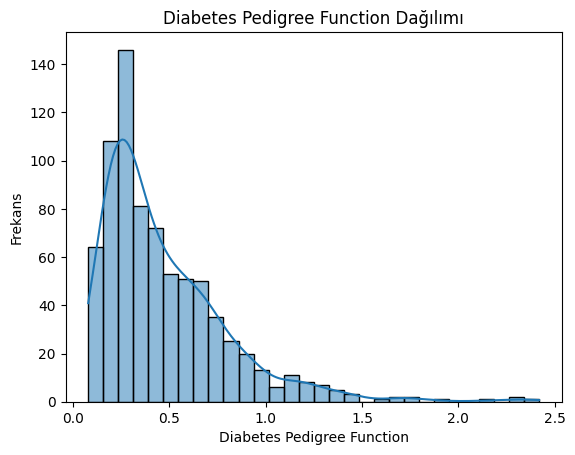

In [29]:
sns.histplot(df["DiabetesPedigreeFunction"], bins=30, kde=True)
plt.title("Diabetes Pedigree Function Dağılımı")
plt.xlabel("Diabetes Pedigree Function")
plt.ylabel("Frekans")
plt.show()

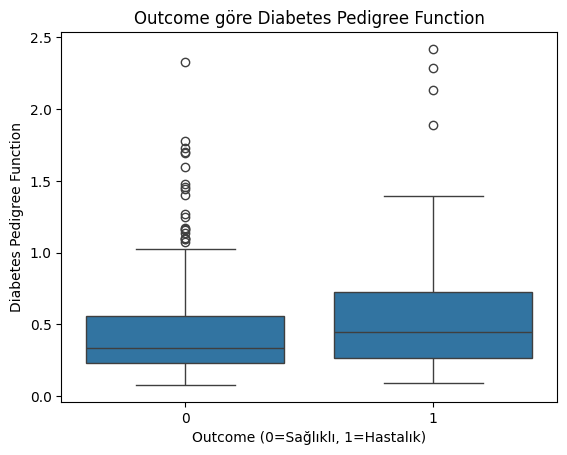

In [31]:
sns.boxplot(x='Outcome', y='DiabetesPedigreeFunction', data=df)
plt.title("Outcome göre Diabetes Pedigree Function")
plt.xlabel("Outcome (0=Sağlıklı, 1=Hastalık)")
plt.ylabel("Diabetes Pedigree Function")
plt.show()

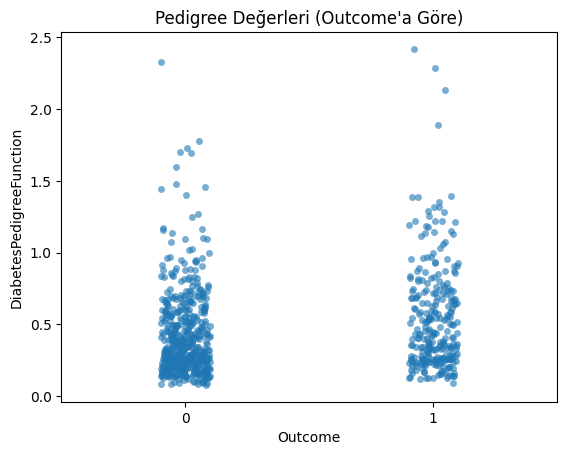

In [33]:
sns.stripplot(x='Outcome', y='DiabetesPedigreeFunction', data=df, jitter=True, alpha=0.6)
plt.title("Pedigree Değerleri (Outcome'a Göre)")
plt.show()

In [35]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [37]:
from sklearn.model_selection import train_test_split

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15)

In [41]:
columns_to_fill = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin','BMI']

In [53]:
medians = {}
for col in columns_to_fill:
    median_value = X_train[X_train[col] != 0][col].median()#X_train[X_train[col] != 0] kısmı, medyan hesaplanırken 0 olan değerlerin hesaba 
    X_train[col] = X_train[col].replace(0, median_value)#katılmamasını sağlar. Eğer 0'ları dahil etseydik, medyan aşağı çekilirdi.
    medians[col] = median_value

for col in columns_to_fill:
    X_test[col] = X_test[col].replace(0, medians[col])

In [55]:
X_train.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,3.907166,121.560261,72.612378,29.040717,142.477199,32.448208,0.469948,33.285016
std,3.385438,29.974412,12.165642,8.312217,80.879330,6.862948,0.328516,11.678337
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.084000,21.000000
25%,1.000000,100.000000,64.000000,25.000000,125.000000,27.600000,0.238250,24.000000
50%,3.000000,117.000000,72.000000,29.000000,129.500000,32.300000,0.370500,29.000000
75%,6.000000,139.750000,80.000000,32.000000,130.000000,36.500000,0.630750,40.000000
max,17.000000,199.000000,122.000000,63.000000,680.000000,67.100000,2.420000,81.000000


In [57]:
X_test.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000
mean,3.597403,122.038961,71.487013,29.376623,144.402597,32.483117,0.479565,33.064935
std,3.304818,32.320876,11.813495,10.513035,104.291511,6.946159,0.343303,12.118519
min,0.000000,61.000000,30.000000,7.000000,23.000000,18.400000,0.078000,21.000000
25%,1.000000,95.250000,64.000000,23.250000,108.250000,26.925000,0.254000,24.000000
50%,3.000000,117.000000,72.000000,29.000000,129.500000,32.300000,0.376500,28.000000
75%,5.750000,142.750000,80.000000,33.750000,129.500000,36.950000,0.603750,41.000000
max,13.000000,197.000000,106.000000,99.000000,846.000000,55.000000,2.329000,69.000000


In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train= scaler.fit_transform(X_train)
X_test= scaler.transform(X_test)

In [67]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [65]:
ada = AdaBoostClassifier()
ada.fit(X_train, y_train)
y_pred = ada.predict(X_test)

In [69]:
print(classification_report(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.81      0.82       108
           1       0.58      0.63      0.60        46

    accuracy                           0.75       154
   macro avg       0.71      0.72      0.71       154
weighted avg       0.76      0.75      0.76       154

0.7532467532467533
[[87 21]
 [17 29]]


In [71]:
# hyperparameter tuning

In [73]:
from sklearn.model_selection import GridSearchCV

In [75]:
adaboost_param = {
    "n_estimators": [50,70,100,120,150,200],
    "learning_rate": [0.001, 0.01, 0.1, 1, 10]
}

In [89]:
grid = GridSearchCV(estimator=AdaBoostClassifier(), param_grid=adaboost_param, cv=5, verbose=1, n_jobs=-1)

In [91]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",AdaBoostClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.001, 0.01, ...], 'n_estimators': [50, 70, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 :

In [93]:
grid.best_params_

{'learning_rate': 1, 'n_estimators': 150}

In [95]:
ada= AdaBoostClassifier(learning_rate= 1, n_estimators= 150)

In [97]:
ada.fit(X_train, y_train)
y_pred = ada.predict(X_test)
print(classification_report(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.81      0.82       108
           1       0.59      0.65      0.62        46

    accuracy                           0.76       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.77      0.76      0.76       154

0.7597402597402597
[[87 21]
 [16 30]]


In [103]:
# Senin şu an kullandığın verileri bu yeni isimlere kopyalıyoruz
X_train_med = X_train.copy()
X_test_med = X_test.copy()
y_train_med = y_train.copy()
y_test_med = y_test.copy()

In [107]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Sadece Medyanlı verilerle modelleri eğitip sonuçları görelim
def ilk_kismi_hesapla(X_tr, X_te, y_tr, y_te):
    modeller = {
        "AdaBoost": AdaBoostClassifier(random_state=42),
        "SVC": SVC(kernel='linear', random_state=42),
        "Random Forest": RandomForestClassifier(random_state=42),
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
    }
    
    for isim, model in modeller.items():
        model.fit(X_tr, y_tr)
        tahmin = model.predict(X_te)
        print(f"\n--- {isim} Sonuçları (Medyan Doldurma) ---")
        print(f"Accuracy: {accuracy_score(y_te, tahmin)}")
        print(classification_report(y_te, tahmin))

# Fonksiyonu çalıştır
ilk_kismi_hesapla(X_train_med, X_test_med, y_train_med, y_test_med)


--- AdaBoost Sonuçları (Medyan Doldurma) ---
Accuracy: 0.7532467532467533
              precision    recall  f1-score   support

           0       0.84      0.81      0.82       108
           1       0.58      0.63      0.60        46

    accuracy                           0.75       154
   macro avg       0.71      0.72      0.71       154
weighted avg       0.76      0.75      0.76       154


--- SVC Sonuçları (Medyan Doldurma) ---
Accuracy: 0.7467532467532467
              precision    recall  f1-score   support

           0       0.82      0.82      0.82       108
           1       0.58      0.57      0.57        46

    accuracy                           0.75       154
   macro avg       0.70      0.69      0.70       154
weighted avg       0.75      0.75      0.75       154


--- Random Forest Sonuçları (Medyan Doldurma) ---
Accuracy: 0.7207792207792207
              precision    recall  f1-score   support

           0       0.81      0.79      0.80       108
           1

In [109]:
#eksik verileri silme

In [111]:
# 0 olan değerleri NaN (boşluk) yapalım ki silebilelim
df_yeni = df.copy()
sutunlar = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df_yeni[sutunlar] = df_yeni[sutunlar].replace(0, np.nan)

# İçinde boşluk olan satırları tamamen sil (Drop işlemi)
df_silinmis = df_yeni.dropna()

# Silinmiş veriyle yeni split yap
X_sil = df_silinmis.drop("Outcome", axis=1)
y_sil = df_silinmis["Outcome"]

X_train_drop, X_test_drop, y_train_drop, y_test_drop = train_test_split(
    X_sil, y_sil, test_size=0.2, random_state=42
)

print(f"Satırlar silindikten sonra kalan toplam veri: {len(df_silinmis)}")

Satırlar silindikten sonra kalan toplam veri: 392


In [113]:
# Az önce yazdığımız fonksiyonu bu sefer 'drop' verileriyle çalıştırıyoruz
ilk_kismi_hesapla(X_train_drop, X_test_drop, y_train_drop, y_test_drop)


--- AdaBoost Sonuçları (Medyan Doldurma) ---
Accuracy: 0.7468354430379747
              precision    recall  f1-score   support

           0       0.79      0.85      0.81        52
           1       0.65      0.56      0.60        27

    accuracy                           0.75        79
   macro avg       0.72      0.70      0.71        79
weighted avg       0.74      0.75      0.74        79


--- SVC Sonuçları (Medyan Doldurma) ---
Accuracy: 0.7341772151898734
              precision    recall  f1-score   support

           0       0.77      0.85      0.81        52
           1       0.64      0.52      0.57        27

    accuracy                           0.73        79
   macro avg       0.70      0.68      0.69        79
weighted avg       0.73      0.73      0.73        79


--- Random Forest Sonuçları (Medyan Doldurma) ---
Accuracy: 0.7848101265822784
              precision    recall  f1-score   support

           0       0.82      0.87      0.84        52
           1

In [119]:
#----------MEDYANLI VERİDE TUNİNG--------
# AdaBoost için en iyi parametreleri arayalım
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0]
}

grid_search = GridSearchCV(AdaBoostClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_med, y_train_med)

print(f"En iyi parametreler: {grid_search.best_params_}")
print(f"En iyi skor: {grid_search.best_score_}")

En iyi parametreler: {'learning_rate': 1.0, 'n_estimators': 100}
En iyi skor: 0.7556843929095028


In [121]:
#------------DROPLU VERİDE TUNİNG--------
# Random Forest Tuning (Drop edilen veride çok iyiydi)
param_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_rf, cv=5)
grid_rf.fit(X_train_drop, y_train_drop)

# SVC Tuning 
param_svc = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}
grid_svc = GridSearchCV(SVC(random_state=42), param_svc, cv=5)
grid_svc.fit(X_train_drop, y_train_drop)

print(f"RF En İyi: {grid_rf.best_score_:.4f} - Parametre: {grid_rf.best_params_}")
print(f"SVC En İyi: {grid_svc.best_score_:.4f} - Parametre: {grid_svc.best_params_}")

RF En İyi: 0.7767 - Parametre: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
SVC En İyi: 0.7926 - Parametre: {'C': 1, 'kernel': 'linear'}
